In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from typing import List, Tuple, Dict, Union, Any


In [3]:
#Game configuration and constants
RED_NUMBERS={1, 3, 5, 7, 9, 12, 14, 16, 18, 19, 21, 23, 25, 27, 30, 32, 34, 36} #SET
BLACK_NUMBERS= {2, 4, 6, 8, 10, 11, 13, 15, 17, 20, 22, 24, 26, 28, 29, 31, 33, 35} #SET

In [4]:
PAYOUTS = {
    "straight": 35, #Straight Up: Bet on one number (35:1 payout).
    "split": 17, #Split: Bet on two adjacent numbers (17:1).
    "street": 11, #Street: Bet on three numbers in a row (11:1).
    "corner": 8, #Corner: Bet on four numbers (8:1).
    "six_line": 5, #Six Line: Bet on six numbers (5:1).
    "dozen": 2, #Dozens (1–12, 13–24, 25–36): Pays 2:1.
    "column": 2, #Columns: Pays 2:1.
    "red": 1, "black": 1, #Red or Black: Pays 1:1.
    "even": 1, "odd": 1, #Odd or Even: Pays 1:1.
    "low": 1, "high": 1 #Low (1–18) or High (19–36): Pays 1:1.
}

In [5]:
def get_roulette_color(number: int) -> str:
    """Returns the color of a roulette number."""
    if number == 0:
        return "green"
    return "red" if number in RED_NUMBERS else "black"

In [6]:
def validate_bet_win(winning_number: int, bet_type: str, bet_value: Any) -> bool:
    """Evaluates if a specific bet won based on the roulette rules."""
    if bet_type in ["straight", "split", "street", "corner", "six_line"]:
        # bet_value should be a list/tuple of numbers covered by the bet
        if isinstance(bet_value, int):
            bet_value = [bet_value]
        return winning_number in bet_value
    
    if winning_number == 0:
        return False  # 0 loses all outside bets
        
    if bet_type == "red": return winning_number in RED_NUMBERS
    if bet_type == "black": return winning_number in BLACK_NUMBERS
    if bet_type == "even": return winning_number % 2 == 0
    if bet_type == "odd": return winning_number % 2 != 0
    if bet_type == "low": return 1 <= winning_number <= 18
    if bet_type == "high": return 19 <= winning_number <= 36
    if bet_type == "dozen":
        if bet_value == 1: return 1 <= winning_number <= 12
        if bet_value == 2: return 13 <= winning_number <= 24
        if bet_value == 3: return 25 <= winning_number <= 36
    if bet_type == "column":
        # Columns are determined by modulo 3
        col = 3 if winning_number % 3 == 0 else winning_number % 3
        return col == bet_value
        
    return False

In [7]:
def calculate_payout(is_win: bool, bet_type: str, bet_amount: float) -> float:
    """Calculates the net profit (or loss) of a bet."""
    if is_win:
        return bet_amount * PAYOUTS[bet_type]
    return -bet_amount

In [8]:
def _get_win_mask_vectorized(rolls: np.ndarray, bet_type: str, bet_value: Any) -> np.ndarray: #ndarray means n-dimensional array
    """Generates a boolean array mapping wins/losses for millions of spins instantly."""
    if bet_type in ["straight", "split", "street", "corner", "six_line"]:
        if isinstance(bet_value, int): bet_value = [bet_value]
        return np.isin(rolls, bet_value)
    
    # 0 loses all outside bets
    not_zero = rolls != 0
    
    if bet_type == "red": return not_zero & np.isin(rolls, list(RED_NUMBERS))
    if bet_type == "black": return not_zero & np.isin(rolls, list(BLACK_NUMBERS))
    if bet_type == "even": return not_zero & (rolls % 2 == 0)
    if bet_type == "odd": return not_zero & (rolls % 2 != 0)
    if bet_type == "low": return not_zero & (rolls >= 1) & (rolls <= 18)
    if bet_type == "high": return not_zero & (rolls >= 19) & (rolls <= 36)
    
    if bet_type == "dozen":
        if bet_value == 1: return not_zero & (rolls >= 1) & (rolls <= 12)
        if bet_value == 2: return not_zero & (rolls >= 13) & (rolls <= 24)
        if bet_value == 3: return not_zero & (rolls >= 25) & (rolls <= 36)
        
    if bet_type == "column":
        cols = np.where(rolls % 3 == 0, 3, rolls % 3)
        return not_zero & (cols == bet_value)
        
    return np.zeros_like(rolls, dtype=bool)

In [9]:
def simulate_roulette(num_spins: int = 1_000_000, bet_amount: float = 1.0, 
                      bet_type: str = "red", bet_value: Any = None, seed: int = 42) -> pd.DataFrame:
    """Runs a Monte Carlo simulation using highly optimized NumPy vectorization."""
    print(f"\nSimulating {num_spins:,} spins for {bet_type} bet...")
    rng = np.random.default_rng(seed)
    
    # 1. Generate all spins instantly
    rolls = rng.integers(0, 37, size=num_spins)
    
    # 2. Evaluate wins
    win_mask = _get_win_mask_vectorized(rolls, bet_type, bet_value)
    
    # 3. Calculate financial arrays
    profit_array = np.where(win_mask, bet_amount * PAYOUTS[bet_type], -bet_amount)
    cumulative_profit = np.cumsum(profit_array)
    cumulative_wagered = np.arange(1, num_spins + 1) * bet_amount
    cumulative_returned = cumulative_wagered + cumulative_profit
    cumulative_rtp = cumulative_returned / cumulative_wagered
    cumulative_house_edge = 1 - cumulative_rtp
    
    # 4. Package into DataFrame
    df = pd.DataFrame({
        "spin_number": np.arange(1, num_spins + 1),
        "winning_number": rolls,
        "is_win": win_mask,
        "profit": profit_array,
        "cumulative_profit": cumulative_profit,
        "cumulative_rtp": cumulative_rtp,
        "cumulative_house_edge": cumulative_house_edge
    })
    
    return df

In [10]:
def theoretical_values(bet_type: str, bet_value: Any = None) -> Dict[str, float]:
    """Calculates the true mathematical expectations for European Roulette."""
    total_pockets = 37
    
    if bet_type in ["straight", "split", "street", "corner", "six_line"]:
        if isinstance(bet_value, int): bet_value = [bet_value]
        win_pockets = len(bet_value)
    elif bet_type in ["red", "black", "even", "odd", "low", "high"]:
        win_pockets = 18
    elif bet_type in ["dozen", "column"]:
        win_pockets = 12
    else:
        win_pockets = 0
        
    p_win = win_pockets / total_pockets
    p_loss = 1 - p_win
    payout = PAYOUTS.get(bet_type, 0)
    
    # Expected Value (EV): P(Win) * Payout + P(Loss) * (-1)
    ev = (p_win * payout) + (p_loss * -1)
    rtp = 1 + ev  # Assuming a 1 unit bet
    house_edge = -ev
    
    # Variance = E[X^2] - (E[X])^2
    e_x2 = (p_win * (payout ** 2)) + (p_loss * (-1 ** 2))
    variance = e_x2 - (ev ** 2)
    std_dev = np.sqrt(variance)
    
    return {
        "p_win": p_win,
        "p_loss": p_loss,
        "ev": ev,
        "rtp": rtp,
        "house_edge": house_edge,
        "variance": variance,
        "std_dev": std_dev
    }

In [11]:
def calculate_statistics(df: pd.DataFrame, bet_type: str, bet_value: Any = None) -> pd.DataFrame:
    """Compares simulated metrics against theoretical mathematics."""
    sim_spins = len(df)
    sim_profit = df["profit"].sum()
    sim_wagered = sim_spins * max(df["profit"]) if len(df["profit"].unique()) == 1 else sim_spins * abs(df["profit"].min())
    sim_returned = sim_wagered + sim_profit
    
    theo = theoretical_values(bet_type, bet_value)
    
    stats = {
        "Metric": [
            "Total Spins", "Hit Frequency", "Expected Value (EV)", "RTP", 
            "House Edge", "Variance", "Standard Deviation"
        ],
        "Theoretical": [
            sim_spins, 
            f"{theo['p_win']:.4%}", 
            f"{theo['ev']:.4f} units", 
            f"{theo['rtp']:.4%}", 
            f"{theo['house_edge']:.4%}", 
            f"{theo['variance']:.4f}", 
            f"{theo['std_dev']:.4f}"
        ],
        "Simulated": [
            sim_spins,
            f"{df['is_win'].mean():.4%}",
            f"{df['profit'].mean():.4f} units",
            f"{sim_returned / sim_wagered:.4%}",
            f"{1 - (sim_returned / sim_wagered):.4%}",
            f"{df['profit'].var(ddof=0):.4f}",
            f"{df['profit'].std(ddof=0):.4f}"
        ]
    }
    
    print("\n" + "="*50)
    print("MATHEMATICAL ANALYSIS & SIMULATION RESULTS")
    print("="*50)
    return pd.DataFrame(stats)

In [12]:
def plot_convergence(df: pd.DataFrame, theo_rtp: float):
    """Plots Law of Large Numbers convergence."""
    fig, axes = plt.subplots(2, 1, figsize=(12, 10))
    
    # We sample the dataframe to speed up plotting if it's huge
    plot_df = df.iloc[::max(1, len(df)//10000), :]
    
    # 1. RTP Convergence
    axes[0].plot(plot_df["spin_number"], plot_df["cumulative_rtp"], label="Simulated RTP", color="blue")
    axes[0].axhline(y=theo_rtp, color="red", linestyle="--", label=f"Theoretical RTP ({theo_rtp:.2%})")
    axes[0].set_title("Law of Large Numbers: RTP Convergence")
    axes[0].set_xlabel("Number of Spins")
    axes[0].set_ylabel("Return to Player (RTP)")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # 2. Cumulative Profit 
    axes[1].plot(plot_df["spin_number"], plot_df["cumulative_profit"], color="purple")
    axes[1].set_title("Cumulative Profit/Loss over Time (Random Walk with Negative Drift)")
    axes[1].set_xlabel("Number of Spins")
    axes[1].set_ylabel("Net Profit (Units)")
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

In [13]:
def plot_payout_distribution(df: pd.DataFrame):
    """Visualizes the discrete probability distribution of payouts."""
    plt.figure(figsize=(8, 6))
    
    
    val_counts = df["profit"].value_counts(normalize=True).sort_index()
    
    ax = sns.barplot(x=val_counts.index, y=val_counts.values, palette="viridis")
    plt.title("Empirical Probability Distribution of Payouts (Discrete)")
    plt.xlabel("Profit (Units)")
    plt.ylabel("Probability")
    
    for i, v in enumerate(val_counts.values):
        ax.text(i, v + 0.01, f"{v:.4f}", ha='center')
        
    plt.show()

In [14]:
def compare_probabilities(df: pd.DataFrame):
    """Checks the uniform distribution of the RNG across all 37 pockets."""
    theo_prob = 1 / 37
    emp_probs = df["winning_number"].value_counts(normalize=True).sort_index()
    
    prob_df = pd.DataFrame({
        "Number": emp_probs.index,
        "Theoretical": theo_prob,
        "Simulated": emp_probs.values
    })
    prob_df["Difference"] = prob_df["Simulated"] - prob_df["Theoretical"]
    
    plt.figure(figsize=(14, 4))
    sns.barplot(data=prob_df, x="Number", y="Simulated", color="skyblue", label="Simulated")
    plt.axhline(theo_prob, color="red", linestyle="--", label="Theoretical (1/37)")
    plt.title("Distribution of Winning Numbers (RNG Integrity Check)")
    plt.legend()
    plt.show()

In [15]:
def interactive_game():
    """Command line interactive loop."""
    print("\n--- EUROPEAN ROULETTE INTERACTIVE TERMINAL ---")
    balance = 1000.0
    while True:
        print(f"\nCurrent Balance: {balance:.2f} units")
        action = input("Press Enter to place a bet, or 'q' to quit: ").lower()
        if action == 'q': break
        
        print("Bet types: straight, red, black, even, odd, dozen, etc.")
        bet_type = input("Enter bet type: ").lower()
        
        bet_value = None
        if bet_type == "straight":
            bet_value = int(input("Enter number (0-36): "))
        elif bet_type == "dozen":
            bet_value = int(input("Enter dozen (1, 2, or 3): "))
            
        bet_amount = float(input("Enter bet amount: "))
        
        if bet_amount > balance:
            print("Insufficient funds!")
            continue
            
        balance -= bet_amount
        win_num = np.random.randint(0, 37)
        color = get_roulette_color(win_num)
        
        print(f"\nSpinning... 🎲 The ball lands on {win_num} {color.upper()}!")
        
        is_win = validate_bet_win(win_num, bet_type, bet_value)
        profit = calculate_payout(is_win, bet_type, bet_amount)
        
        if is_win:
            returned = bet_amount + profit
            balance += returned
            print(f"✅ WIN! You profit {profit:.2f}. Total returned: {returned:.2f}")
        else:
            print(f"❌ LOSS. You lose {abs(profit):.2f}.")


Simulating 1,000,000 spins for straight bet...

MATHEMATICAL ANALYSIS & SIMULATION RESULTS
             Metric   Theoretical     Simulated
        Total Spins       1000000       1000000
      Hit Frequency       2.7027%       2.6885%
Expected Value (EV) -0.0270 units -0.0321 units
                RTP      97.2973%      96.7860%
         House Edge       2.7027%       3.2140%
           Variance       32.1344       33.9062
 Standard Deviation        5.6687        5.8229


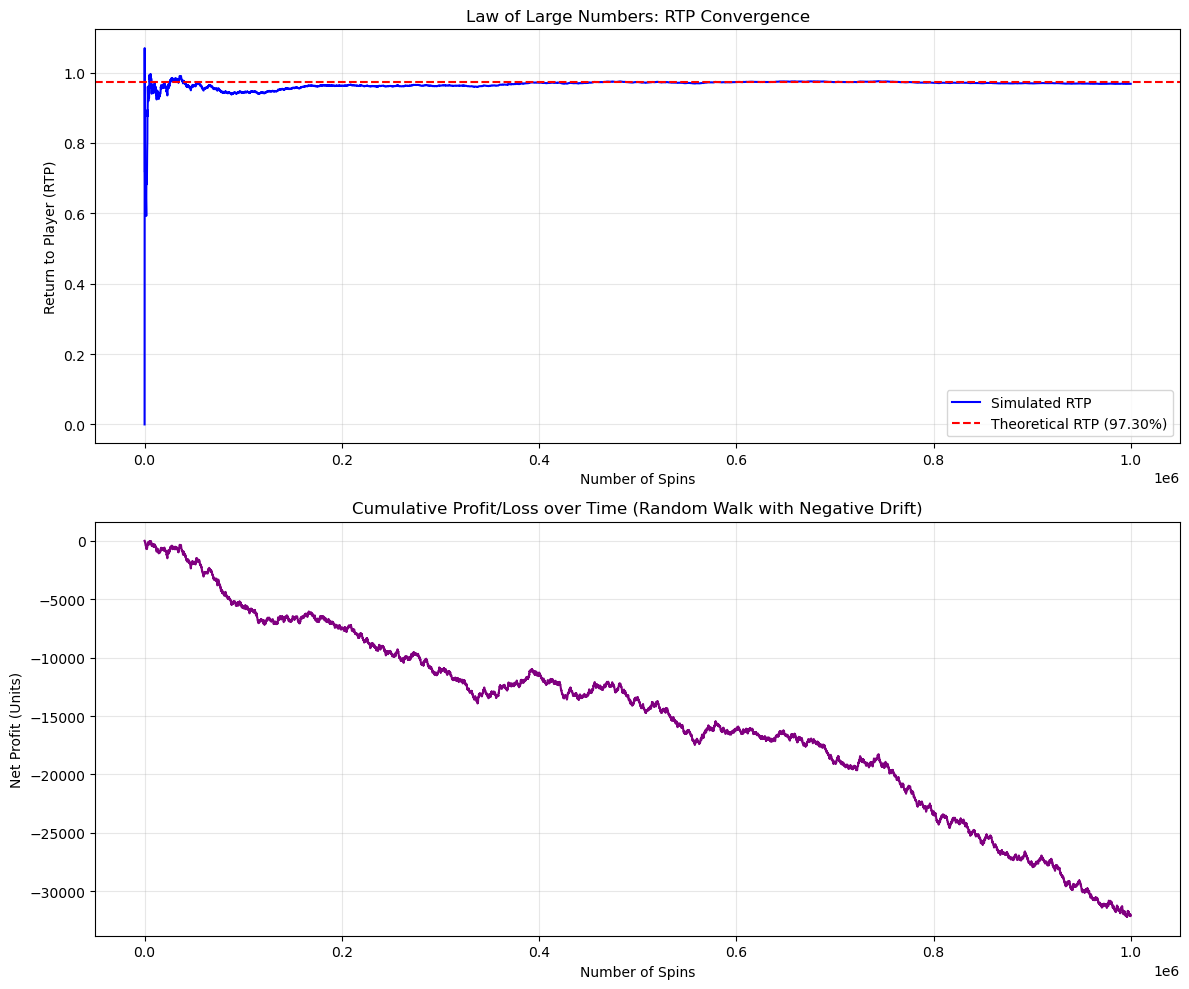

C:\Users\Dell\AppData\Local\Temp\ipykernel_24272\2395235143.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=val_counts.index, y=val_counts.values, palette="viridis")


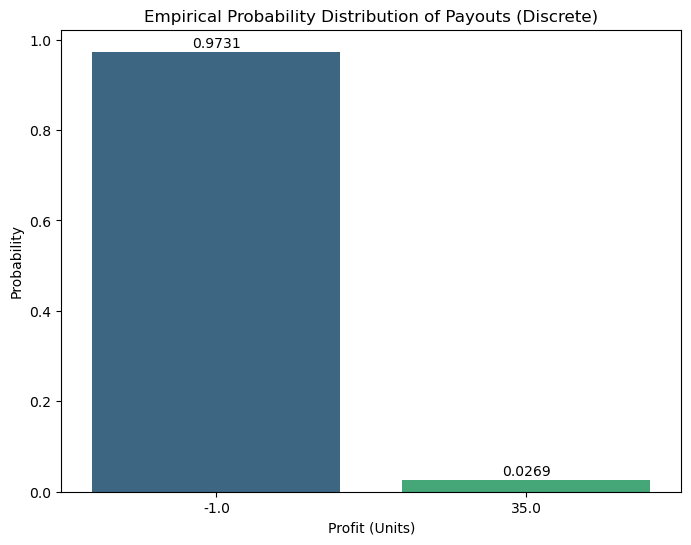

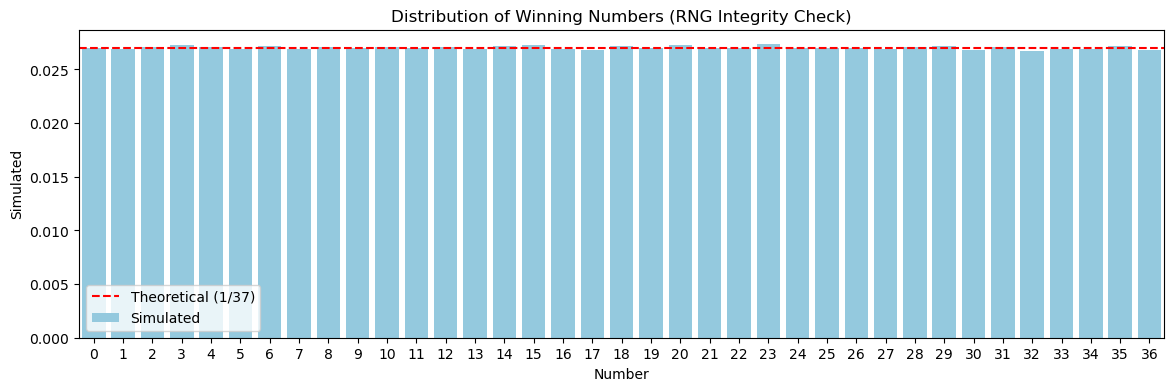

In [16]:

# MAIN EXECUTION

if __name__ == "__main__":
    # To play interactively, uncomment the line below:
    # interactive_game()
    
    # 1. Run 1,000,000 spin simulation for a Straight Up bet on number 7
    df_sim = simulate_roulette(num_spins=1_000_000, bet_type="straight", bet_value=[7])
    
    # 2. Calculate and display mathematical breakdown
    stats_df = calculate_statistics(df_sim, bet_type="straight", bet_value=[7])
    print(stats_df.to_string(index=False))
    
    # 3. Visualizations
    theo = theoretical_values("straight", [7])
    plot_convergence(df_sim, theo["rtp"])
    plot_payout_distribution(df_sim)
    compare_probabilities(df_sim)

In [ ]:
result=interactive_game()
print(result)


--- EUROPEAN ROULETTE INTERACTIVE TERMINAL ---

Current Balance: 1000.00 units
Bet types: straight, red, black, even, odd, dozen, etc.
